In [1]:
import os

# 1. Point this to the actual folder where your project/notebook lives
os.chdir(r"C:\Users\khana\OneDrive\Desktop\ETA-Prediction") 

# 2. Verify it changed successfully
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\khana\OneDrive\Desktop\ETA-Prediction


In [3]:
pip install "numpy<2.0" --force-reinstall

Note: you may need to restart the kernel to use updated packages.Collecting numpy<2.0
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2



  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [2]:
import pandas as pd
df = pd.read_csv("cleaned_data/cleaned_dataset.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268112 entries, 0 to 268111
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        268112 non-null  int64  
 1   restaurant_id             268112 non-null  int64  
 2   rider_id                  268112 non-null  float64
 3   drop_lat                  262762 non-null  float64
 4   drop_lon                  262762 non-null  float64
 5   order_size                268112 non-null  int64  
 6   order_value               268112 non-null  float64
 7   timestamp                 268112 non-null  object 
 8   promised_eta              254450 non-null  float64
 9   actual_delivery_time_min  268112 non-null  float64
 10  order_status              268112 non-null  object 
 11  hour                      268112 non-null  int64  
 12  day                       268112 non-null  int64  
 13  month                     268112 non-null  i

In [3]:
print(df.columns.tolist())

['id', 'restaurant_id', 'rider_id', 'drop_lat', 'drop_lon', 'order_size', 'order_value', 'timestamp', 'promised_eta', 'actual_delivery_time_min', 'order_status', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'id_restaurant', 'name', 'lat', 'lon', 'cuisine', 'avg_rating', 'prep_capacity', 'id_rider', 'lat_rider', 'lon_rider', 'vehicle_type', 'completed_orders', 'shift_hours', 'current_load']


In [4]:
df["timestamp"]

0         2026-05-06 19:22:36
1         2026-05-18 22:56:00
2         2026-06-05 19:20:00
3         2026-05-16 19:39:57
4         2026-05-19 19:50:36
                 ...         
268107    2026-06-21 21:41:04
268108    2026-05-01 15:29:18
268109    2026-05-24 21:47:00
268110    2026-06-03 19:14:22
268111    2026-05-13 18:04:00
Name: timestamp, Length: 268112, dtype: object

In [5]:
df.shape

(268112, 30)

In [6]:
df.columns

Index(['id', 'restaurant_id', 'rider_id', 'drop_lat', 'drop_lon', 'order_size',
       'order_value', 'timestamp', 'promised_eta', 'actual_delivery_time_min',
       'order_status', 'hour', 'day', 'month', 'weekday', 'is_weekend',
       'id_restaurant', 'name', 'lat', 'lon', 'cuisine', 'avg_rating',
       'prep_capacity', 'id_rider', 'lat_rider', 'lon_rider', 'vehicle_type',
       'completed_orders', 'shift_hours', 'current_load'],
      dtype='object')

In [7]:
df.dtypes

id                            int64
restaurant_id                 int64
rider_id                    float64
drop_lat                    float64
drop_lon                    float64
order_size                    int64
order_value                 float64
timestamp                    object
promised_eta                float64
actual_delivery_time_min    float64
order_status                 object
hour                          int64
day                           int64
month                         int64
weekday                      object
is_weekend                     bool
id_restaurant                 int64
name                         object
lat                         float64
lon                         float64
cuisine                      object
avg_rating                  float64
prep_capacity                 int64
id_rider                    float64
lat_rider                   float64
lon_rider                   float64
vehicle_type                 object
completed_orders            

In [8]:
df.describe()

,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,promised_eta,actual_delivery_time_min,hour,...,lat,lon,avg_rating,prep_capacity,id_rider,lat_rider,lon_rider,completed_orders,shift_hours,current_load
count,268112.000000,268112.000000,268112.000000,262762.000000,262762.000000,268112.000000,268112.000000,254450.000000,268112.000000,268112.000000,...,268112.000000,268112.000000,246751.000000,268112.000000,268112.000000,263104.000000,263104.000000,268112.000000,268112.000000,268112.000000
mean,150070.230008,1994.382762,2997.182644,12.971575,77.594595,2.924390,444.224283,21.765121,25.614980,16.102532,...,12.971652,77.594483,3.851275,13.833588,2997.182644,12.971771,77.594670,848.437198,5.610130,1.434781
std,86632.277812,1152.238589,1733.637321,0.012711,0.012692,1.817119,320.068122,6.699863,9.728087,4.409015,...,0.009293,0.009236,0.610094,24.557863,1733.637321,0.011647,0.011562,1146.707769,3.426565,1.385038
min,1.000000,1.000000,1.000000,12.949600,77.572600,0.000000,-1756.960000,10.000000,8.000000,7.000000,...,12.955605,77.578604,2.800000,0.000000,1.000000,12.951603,77.574632,0.000000,0.000000,-1.000000
25%,75015.750000,1002.000000,1500.000000,12.960565,77.583603,1.000000,211.127500,15.000000,19.200000,12.000000,...,12.963688,77.586566,3.300000,6.000000,1500.000000,12.961511,77.584647,37.000000,2.700000,0.000000
50%,150136.500000,1997.000000,3001.000000,12.971559,77.594599,2.000000,376.450000,20.000000,24.300000,17.000000,...,12.971710,77.594381,3.800000,10.000000,3001.000000,12.972036,77.594615,289.000000,5.500000,1.000000
75%,225076.250000,2987.000000,4494.000000,12.982602,77.605582,4.000000,610.200000,25.000000,30.400000,20.000000,...,12.979712,77.602446,4.400000,15.000000,4494.000000,12.981939,77.604944,1355.000000,8.300000,2.000000
max,300000.000000,4000.000000,6000.000000,12.993600,77.616600,8.000000,1806.620000,60.000000,108.200000,23.000000,...,12.987587,77.610599,4.900000,200.000000,6000.000000,12.991596,77.614597,3997.000000,19.800000,5.000000


In [9]:
df["timestamp"].dtype

dtype('O')

In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [11]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [12]:
df["hour"] = df["timestamp"].dt.hour

In [13]:
df["weekday"] = df["timestamp"].dt.dayofweek

In [14]:
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

In [15]:
df["peak_hour"] = (
    df["hour"].between(11,14) |
    df["hour"].between(18,22)
).astype(int)

Rider → Restaurant Distance (Haversine Formula)

In [16]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two GPS coordinates in kilometers.
    """

    R = 6371  # Earth radius in KM

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [17]:
print(df.columns.tolist())

['id', 'restaurant_id', 'rider_id', 'drop_lat', 'drop_lon', 'order_size', 'order_value', 'timestamp', 'promised_eta', 'actual_delivery_time_min', 'order_status', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'id_restaurant', 'name', 'lat', 'lon', 'cuisine', 'avg_rating', 'prep_capacity', 'id_rider', 'lat_rider', 'lon_rider', 'vehicle_type', 'completed_orders', 'shift_hours', 'current_load', 'peak_hour']


In [18]:
df["rider_restaurant_distance"] = df.apply(
    lambda row: haversine(
        row["lat_rider"],
        row["lon_rider"],
        row["lat"],
        row["lon"]
    ),
    axis=1
)

In [19]:
df["rider_restaurant_distance"].head()

0    1.381681
1    2.601042
2    1.540827
3    2.939654
4    1.818574
Name: rider_restaurant_distance, dtype: float64

Restaurant → Customer Distance

In [20]:
df["restaurant_customer_distance"] = df.apply(
    lambda row: haversine(
        row["lat"],
        row["lon"],
        row["drop_lat"],
        row["drop_lon"]
    ),
    axis=1
)

In [21]:
df["restaurant_customer_distance"].head()

0    0.618594
1    2.984424
2    1.419790
3    1.842754
4    2.095500
Name: restaurant_customer_distance, dtype: float64

Estimated Travel Time

In [22]:
speed_map = {
    "bike": 40,
    "scooter": 45,
    "car": 35,
    "bicycle": 15
}

In [23]:
df["vehicle_type"] = df["vehicle_type"].str.lower().str.strip()

In [24]:
df["vehicle_speed"] = df["vehicle_type"].map(speed_map)

In [25]:
df[["vehicle_type", "vehicle_speed"]].head(20)

,vehicle_type,vehicle_speed
0,bike,40
1,bike,40
2,car,35
3,car,35
4,car,35
5,bike,40
6,bike,40
7,bike,40
8,bicycle,15
9,car,35


In [26]:
df["estimated_travel_time"] = (
    df["restaurant_customer_distance"] /
    df["vehicle_speed"]
) * 60

In [27]:
df["estimated_travel_time"].head()

0    0.927890
1    4.476636
2    2.433926
3    3.159006
4    3.592285
Name: estimated_travel_time, dtype: float64

Restaurant Load

In [28]:
df["restaurant_load"] = (
    df["order_size"] *
    df["prep_capacity"]
)

In [29]:
df["restaurant_load_ratio"] = (
    df["current_load"] /
    (df["prep_capacity"] + 1)
)

Rider Experience

In [30]:
def rider_experience(x):

    if x <= 500:
        return "Beginner"

    elif x <= 2000:
        return "Intermediate"

    else:
        return "Expert"

In [31]:
df["rider_experience"] = df["completed_orders"].apply(rider_experience)

In [32]:
df["rider_experience"].value_counts()

rider_experience
Beginner        179008
Expert           51355
Intermediate     37749
Name: count, dtype: int64

Restaurant Efficiency

In [33]:
df["restaurant_efficiency"] = (
    df["avg_rating"] *
    df["prep_capacity"]
)

In [34]:
df["load_ratio"] = (
    df["current_load"] /
    (df["prep_capacity"] + 1)
)

In [35]:
df["order_complexity"] = (
    df["order_size"] *
    df["order_value"]
)

In [36]:
df["total_distance"] = (
    df["rider_restaurant_distance"] +
    df["restaurant_customer_distance"]
)

In [38]:
for col in ["drop_lat", "drop_lon", "lat_rider", "lon_rider"]:
    df[col] = df[col].fillna(df[col].median())

df["promised_eta"] = df["promised_eta"].fillna(df["promised_eta"].median())
df["avg_rating"]   = df["avg_rating"].fillna(df["avg_rating"].median())

print("Nulls remaining:", df.isnull().sum()[df.isnull().sum() > 0].to_dict())

Nulls remaining: {'rider_restaurant_distance': 5008, 'restaurant_customer_distance': 5350, 'estimated_travel_time': 5350, 'restaurant_efficiency': 21361, 'total_distance': 10258}


In [39]:
new_features = [
    "rider_restaurant_distance",
    "restaurant_customer_distance",
    "vehicle_speed",
    "estimated_travel_time",
    "restaurant_load",
    "restaurant_load_ratio",
    "rider_experience",
    "restaurant_efficiency",
    "load_ratio",
    "order_complexity"
]

df[new_features].head()

,rider_restaurant_distance,restaurant_customer_distance,vehicle_speed,estimated_travel_time,restaurant_load,restaurant_load_ratio,rider_experience,restaurant_efficiency,load_ratio,order_complexity
0,1.381681,0.618594,40,0.927890,140,0.047619,Beginner,78.0,0.047619,5907.02
1,2.601042,2.984424,40,4.476636,8,0.111111,Expert,33.6,0.111111,156.37
2,1.540827,1.419790,35,2.433926,20,0.181818,Expert,34.0,0.181818,580.30
3,2.939654,1.842754,35,3.159006,24,0.000000,Intermediate,54.0,0.000000,329.54
4,1.818574,2.095500,35,3.592285,30,0.187500,Beginner,69.0,0.187500,768.92


In [40]:

categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['order_status', 'name', 'cuisine', 'vehicle_type', 'rider_experience'], dtype='object')


In [41]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [42]:
print(df.shape)
df.head()

(268112, 274)


,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,timestamp,promised_eta,actual_delivery_time_min,...,cuisine_Continental,cuisine_Fast Food,cuisine_Healthy Bowls,cuisine_Italian,cuisine_North Indian,cuisine_South Indian,vehicle_type_bike,vehicle_type_car,rider_experience_Expert,rider_experience_Intermediate
0,1,1921,5764.0,12.967183,77.601366,7,843.86,2026-05-06 19:22:36,15.0,22.2,...,False,False,False,False,False,False,True,False,False,False
1,2,417,3377.0,12.985586,77.615225,1,156.37,2026-05-18 22:56:00,15.0,19.2,...,False,False,False,True,False,False,True,False,True,False
2,3,692,3424.0,12.956571,77.608251,2,290.15,2026-06-05 19:20:00,20.0,20.1,...,False,False,False,False,True,False,False,True,True,False
3,4,140,861.0,12.950077,77.590249,2,164.77,2026-05-16 19:39:57,20.0,18.6,...,False,False,False,False,False,False,False,True,False,True
4,5,189,4881.0,12.972294,77.579577,2,384.46,2026-05-19 19:50:36,20.0,20.1,...,False,False,False,False,False,False,False,True,False,False


In [43]:
print(df.columns.tolist())

['id', 'restaurant_id', 'rider_id', 'drop_lat', 'drop_lon', 'order_size', 'order_value', 'timestamp', 'promised_eta', 'actual_delivery_time_min', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'id_restaurant', 'lat', 'lon', 'avg_rating', 'prep_capacity', 'id_rider', 'lat_rider', 'lon_rider', 'completed_orders', 'shift_hours', 'current_load', 'peak_hour', 'rider_restaurant_distance', 'restaurant_customer_distance', 'vehicle_speed', 'estimated_travel_time', 'restaurant_load', 'restaurant_load_ratio', 'restaurant_efficiency', 'load_ratio', 'order_complexity', 'total_distance', 'name_Bombay Bites', 'name_Bombay Bowl', 'name_Bombay Box', 'name_Bombay Cafe', 'name_Bombay Corner', 'name_Bombay Diner', 'name_Bombay Eats', 'name_Bombay Express', 'name_Bombay House', 'name_Bombay Hub', 'name_Bombay Junction', 'name_Bombay Kitchen', 'name_Bombay Plate', 'name_Bombay Treats', 'name_Cloud Bistro', 'name_Cloud Bites', 'name_Cloud Bowl', 'name_Cloud Box', 'name_Cloud Cafe', 'name_Cloud Corner', 'na

In [44]:
columns_to_drop = [
    "id",
    "restaurant_id",
    "rider_id",
    "id_restaurant",
    "id_rider",
    "timestamp"
]


columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

print("Dropped:", columns_to_drop)

Dropped: ['id', 'restaurant_id', 'rider_id', 'id_restaurant', 'id_rider', 'timestamp']


In [45]:
name_columns = [col for col in df.columns if col.startswith("name_")]

print("Restaurant name columns:", len(name_columns))

df.drop(columns=name_columns, inplace=True)

Restaurant name columns: 224


In [46]:
print(df.shape)

print(df.columns.tolist())

(268112, 44)
['drop_lat', 'drop_lon', 'order_size', 'order_value', 'promised_eta', 'actual_delivery_time_min', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'lat', 'lon', 'avg_rating', 'prep_capacity', 'lat_rider', 'lon_rider', 'completed_orders', 'shift_hours', 'current_load', 'peak_hour', 'rider_restaurant_distance', 'restaurant_customer_distance', 'vehicle_speed', 'estimated_travel_time', 'restaurant_load', 'restaurant_load_ratio', 'restaurant_efficiency', 'load_ratio', 'order_complexity', 'total_distance', 'cuisine_Beverages', 'cuisine_Biryani', 'cuisine_Chinese', 'cuisine_Continental', 'cuisine_Fast Food', 'cuisine_Healthy Bowls', 'cuisine_Italian', 'cuisine_North Indian', 'cuisine_South Indian', 'vehicle_type_bike', 'vehicle_type_car', 'rider_experience_Expert', 'rider_experience_Intermediate']


In [47]:
target = "actual_delivery_time_min"
X = df.drop(columns=[target])
y = df[target]

In [48]:
print(X.shape)
print(y.shape)

(268112, 43)
(268112,)


In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [50]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (214489, 43)
Testing : (53623, 43)


In [51]:
df.to_csv(
    "processed_dataset.csv",
    index=False
)

print("Feature engineering completed successfully!")

Feature engineering completed successfully!


In [52]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Train-Test datasets saved successfully!")

Train-Test datasets saved successfully!


In [60]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 1.0 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.3 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.2 MB/s eta 0:00:00


In [53]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

In [54]:
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

In [55]:
model.fit(
    X_train,
    y_train
)

print("Model Training Completed")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3949
[LightGBM] [Info] Number of data points in the train set: 214489, number of used features: 43
[LightGBM] [Info] Start training from score 25.602950
Model Training Completed


In [56]:
y_pred = model.predict(X_test)

In [57]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

In [58]:
print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R2 Score:", round(r2,3))
print("MAPE:", round(mape,3))

MAE : 3.143
RMSE: 6.393
R2 Score: 0.585
MAPE: 0.129


In [59]:
import matplotlib.pyplot as plt
importance = model.feature_importances_
feature_names = X_train.columns

In [60]:
importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

In [61]:
importance_df.head(20)

,Feature,Importance
29,total_distance,1009
4,promised_eta,813
20,rider_restaurant_distance,692
23,estimated_travel_time,629
2,order_size,572
22,vehicle_speed,396
5,hour,369
26,restaurant_efficiency,369
17,shift_hours,327
28,order_complexity,284


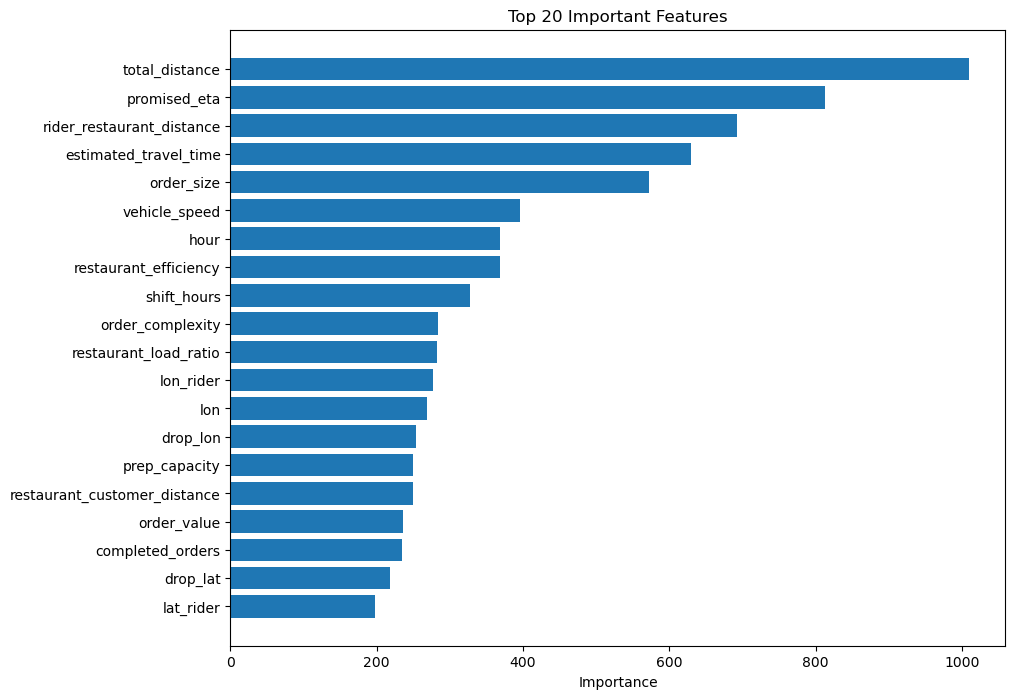

In [62]:
plt.figure(figsize=(10,8))

plt.barh(
    importance_df["Feature"][:20],
    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

In [63]:
import joblib

joblib.dump(
    model,
    "eta_prediction_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [64]:
sample = X_test.iloc[[0]]
prediction = model.predict(sample)
print("Predicted ETA:", prediction[0])
print("Actual ETA:", y_test.iloc[0])

Predicted ETA: 36.538860999720384
Actual ETA: 37.2


In [65]:
comparison = X_test.head(50).copy()
comparison["Actual"] = y_test.head(50)
comparison["Predicted"] = model.predict(X_test.head(50))
comparison["Error (Mins)"] = (
    comparison["Actual"] - comparison["Predicted"]
).abs()

print(comparison[["Actual", "Predicted", "Error (Mins)"]])

        Actual  Predicted  Error (Mins)
242461    37.2  36.538861      0.661139
136097    26.1  24.856496      1.243504
95442     23.9  23.135167      0.764833
175307    20.6  23.580234      2.980234
223525    26.3  31.202987      4.902987
30818     31.8  28.423253      3.376747
223996    16.7  21.085695      4.385695
111607    32.7  29.880602      2.819398
81239     25.6  27.446422      1.846422
231717    30.9  24.910977      5.989023
173608    35.9  37.751192      1.851192
23368     16.0  18.026906      2.026906
264271    23.4  26.606598      3.206598
52197     14.7  18.744373      4.044373
50863     19.5  21.762409      2.262409
213027    13.3  12.684557      0.615443
32103     19.8  19.825844      0.025844
247888    16.1  14.441129      1.658871
153072    23.9  22.276447      1.623553
136773    37.8  34.856762      2.943238
48861      8.0  13.455234      5.455234
262176    34.7  34.596706      0.103294
72292     22.7  28.316885      5.616885
180691    17.7  13.276813      4.423187


In [66]:
results = X_test.copy()
results["Actual_ETA"] = y_test.values
results["Predicted_ETA"] = y_pred
results.to_csv(
    "prediction_results.csv",
    index=False
)

print("Prediction results saved!")

Prediction results saved!


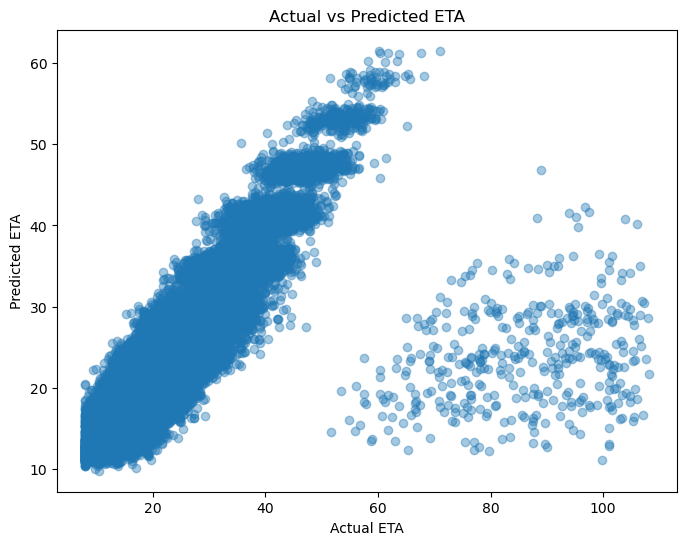

In [67]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual ETA")
plt.ylabel("Predicted ETA")
plt.title("Actual vs Predicted ETA")
plt.show()

Tuning

In [78]:
!pip install scikit-learn

In [68]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

params = {
    "num_leaves":[20,31,50],
    "max_depth":[5,8,10,-1],
    "learning_rate":[0.01,0.05,0.1],
    "n_estimators":[200,300,500],
    "min_child_samples":[10,20,30]
}

lgb = LGBMRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=params,
    n_iter=20,
    cv=3,
    scoring="neg_mean_absolute_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058364 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3949
[LightGBM] [Info] Number of data points in the train set: 214489, number of used features: 43
[LightGBM] [Info] Start training from score 25.602950
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


RandomizedSearchCV(cv=3, estimator=LGBMRegressor(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [5, 8, 10, -1],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [200, 300, 500],
                                        'num_leaves': [20, 31, 50]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [69]:
print(random_search.best_params_)

{'num_leaves': 20, 'n_estimators': 500, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.05}


In [70]:
import joblib

best_model = random_search.best_estimator_

joblib.dump(best_model, "best_lightgbm_eta_model.pkl")
print("Model saved successfully as a .pkl file!")

Model saved successfully as a .pkl file!


In [84]:
!pip install "numpy<2.0" --force-reinstall

   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.5 MB 3.4 MB/s eta 0:00:05
   -- ------------------------------------- 0.8/15.5 MB 1.1 MB/s eta 0:00:14
   -- ------------------------------------- 0.8/15.5 MB 1.1 MB/s eta 0:00:14
   --- ------------------------------------ 1.3/15.5 MB 1.3 MB/s eta 0:00:11
   ---- ----------------------------------- 1.8/15.5 MB 1.5 MB/s eta 0:00:09
   ----- ---------------------------------- 2.1/15.5 MB 1.5 MB/s eta 0:00:10
   ------ --------------------------------- 2.4/15.5 MB 1.5 MB/s eta 0:00:09
   ------ --------------------------------- 2.6/15.5 MB 1.5 MB/s eta 0:00:09
   ------- -------------------------------- 2.9/15.5 MB 1.4 MB/s eta 0:00:10
   -------- ------------------------------- 3.1/15.5 MB 1.4 MB/s eta 0:00:09
   -------- --------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [85]:
!pip install shap

  Using cached numpy-2.5.0-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl (15.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.


In [71]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

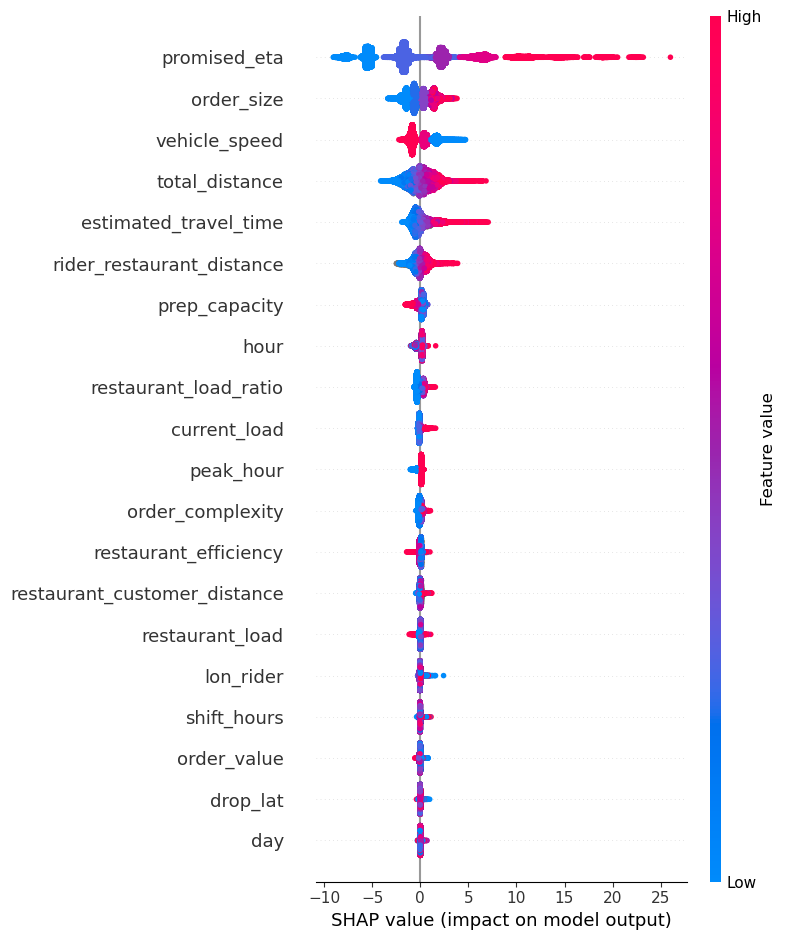

In [72]:
shap.summary_plot(shap_values, X_test)